# 🔮 Customer Churn Prediction
### Complete ML Pipeline — BCS-8B University Project
**Stack:** Python · Scikit-learn · XGBoost · Streamlit · Gemini AI · Pinecone RAG

---
### 📋 Table of Contents
1. Install Libraries
2. Import Libraries
3. Load Dataset
4. Exploratory Data Analysis (EDA)
5. Data Cleaning & Preprocessing
6. Train-Test Split & Feature Scaling
7. Train 3 ML Models
8. Evaluate All Models
9. Confusion Matrix & ROC Curve
10. Feature Importance
11. Save Model & Scaler


## Step 1 — Install Required Libraries

In [1]:
!pip install streamlit scikit-learn xgboost pandas numpy seaborn matplotlib pinecone-client google-generativeai -q
print("✅ All libraries installed!")

✅ All libraries installed!


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-google-genai 2.1.5 requires google-ai-generativelanguage<0.7.0,>=0.6.18, but you have google-ai-generativelanguage 0.6.10 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.6 which is incompatible.
paddlepaddle 2.6.2 requires protobuf<=3.20.2,>=3.1.0; platform_system == "Windows", but you have protobuf 5.29.6 which is incompatible.
surya-ocr 0.7.0 requires opencv-python<5.0.0.0,>=4.9.0.80, but you have opencv-python 4.8.1.78 which is incompatible.
surya-ocr 0.7.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
tensorboard 2.10.1 requires protobuf<3.20,>=3.9.2, but you have protobuf 5.29.6 which is incompatible.
tensorboardx 2.6 requires protobuf<4,>=3.8.0, but you have protobuf 5.29.6 which is incompatible.
tenso

## Step 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

print("✅ All imports successful!")

✅ All imports successful!


## Step 3 — Load Dataset
> **How to get the dataset:**
> 1. Go to [kaggle.com](https://www.kaggle.com)
> 2. Search: `Telco Customer Churn`
> 3. Download `WA_Fn-UseC_-Telco-Customer-Churn.csv`
> 4. Upload it to this Colab session (folder icon on left → upload)

In [3]:
# If running on Google Colab, upload the CSV first using the sidebar
# Then run this cell

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 4 — Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("=== Dataset Info ===")
print(df.info())
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Churn Distribution ===")
print(df["Churn"].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

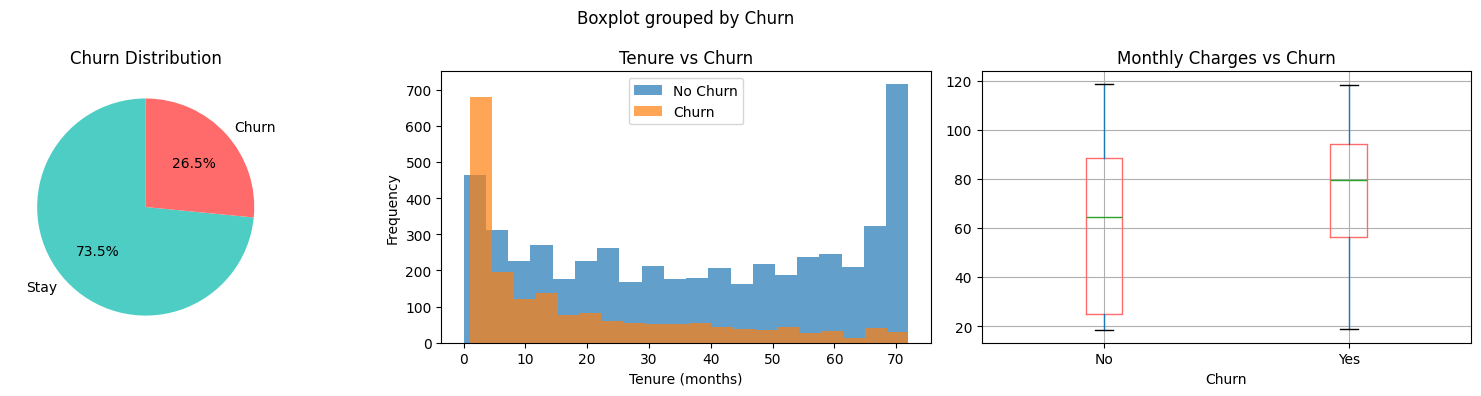

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold")

# Churn distribution
axes[0].pie(
    df["Churn"].value_counts(),
    labels=["Stay", "Churn"],
    colors=["#4ECDC4", "#FF6B6B"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Churn Distribution")

# Tenure vs Churn
df.groupby("Churn")["tenure"].plot(kind="hist", alpha=0.7, ax=axes[1], bins=20)
axes[1].legend(["No Churn", "Churn"])
axes[1].set_title("Tenure vs Churn")
axes[1].set_xlabel("Tenure (months)")

# Monthly Charges vs Churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[2], 
           boxprops=dict(color="#FF6B6B"))
axes[2].set_title("Monthly Charges vs Churn")
axes[2].set_xlabel("Churn")

plt.tight_layout()
plt.show()

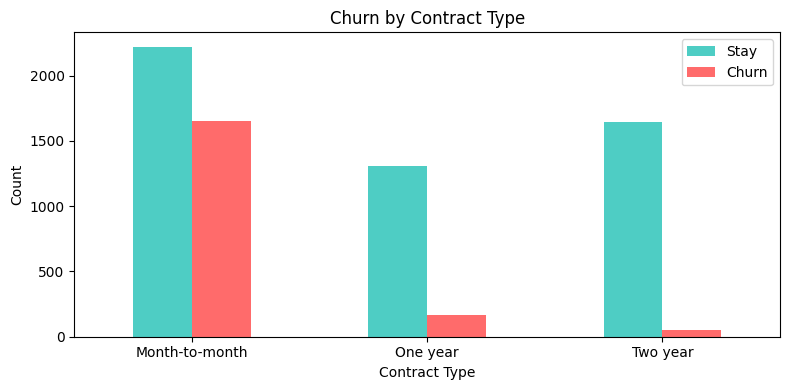

In [6]:
# Churn by Contract Type
plt.figure(figsize=(8, 4))
contract_churn = df.groupby(["Contract", "Churn"]).size().unstack()
contract_churn.plot(kind="bar", color=["#4ECDC4", "#FF6B6B"], ax=plt.gca(), rot=0)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(["Stay", "Churn"])
plt.tight_layout()
plt.show()

## Step 5 — Data Cleaning & Preprocessing

In [7]:
df_clean = df.copy()

# Drop customerID — not useful for prediction
df_clean = df_clean.drop("customerID", axis=1)

# Fix TotalCharges — it's stored as string, convert to float
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Drop rows with missing values (only ~11 rows)
df_clean.dropna(inplace=True)
print(f"Rows after dropping NaN: {len(df_clean)}")

# Encode target: Yes → 1, No → 0
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode all categorical columns
df_clean = pd.get_dummies(df_clean, drop_first=True)

print(f"\nFinal shape: {df_clean.shape}")
print(f"\nSample columns: {list(df_clean.columns[:10])}")
df_clean.head()

Rows after dropping NaN: 7032

Final shape: (7032, 31)

Sample columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Step 6 — Train-Test Split & Feature Scaling

In [8]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")

# 80% train, 20% test — stratify keeps same churn ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

# Scale features — important for Distance/Gradient based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Data split and scaled!")

Features (X): (7032, 30)
Target  (y): (7032,)
Class balance: {0: 5163, 1: 1869}

Train size: 5625 samples
Test size:  1407 samples

✅ Data split and scaled!


## Step 7 — Train 3 ML Models

In [9]:
models = {
    "Decision Tree":  DecisionTreeClassifier(random_state=42),
    "Random Forest":  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":        XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
}

trained = {}
print("Training models...\n")

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, proba)
    trained[name] = {
        "model": model, "preds": preds, "proba": proba,
        "acc": acc, "auc": auc,
        "report": classification_report(y_test, preds, output_dict=True),
        "cm": confusion_matrix(y_test, preds)
    }
    print(f"  {name:<20} Accuracy: {acc:.4f}   AUC: {auc:.4f}")

print("\n✅ All models trained!")

Training models...

  Decision Tree        Accuracy: 0.7164   AUC: 0.6343
  Random Forest        Accuracy: 0.7882   AUC: 0.8156
  XGBoost              Accuracy: 0.7669   AUC: 0.8142

✅ All models trained!


## Step 8 — Compare All Models

               Accuracy  ROC-AUC  Precision(1)  Recall(1)  F1-Score(1)
Model                                                                 
Decision Tree    0.7164   0.6343        0.4661     0.4599       0.4630
Random Forest    0.7882   0.8156        0.6234     0.5134       0.5630
XGBoost          0.7669   0.8142        0.5676     0.5160       0.5406


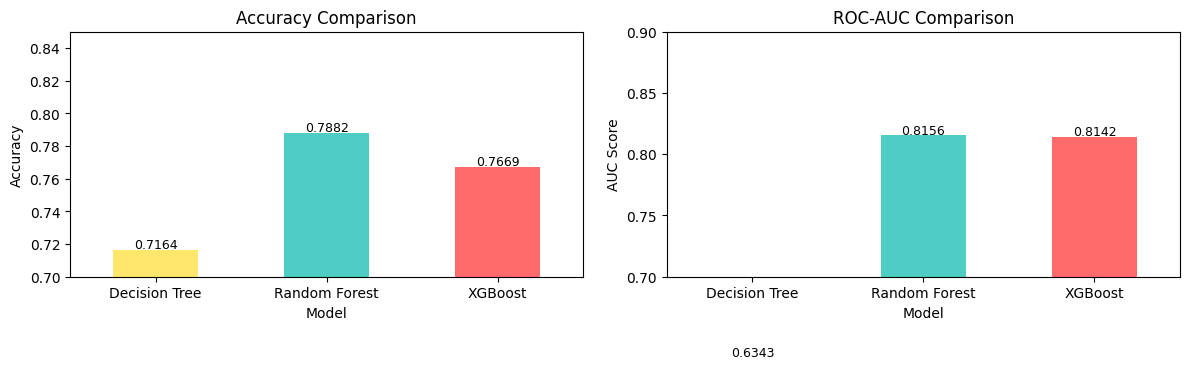

In [10]:
# Summary table
summary = []
for name, res in trained.items():
    r = res["report"]
    summary.append({
        "Model":          name,
        "Accuracy":       round(res["acc"], 4),
        "ROC-AUC":        round(res["auc"], 4),
        "Precision(1)":   round(r["1"]["precision"], 4),
        "Recall(1)":      round(r["1"]["recall"], 4),
        "F1-Score(1)":    round(r["1"]["f1-score"], 4),
    })

summary_df = pd.DataFrame(summary).set_index("Model")
print(summary_df.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#FFE66D", "#4ECDC4", "#FF6B6B"]

summary_df["Accuracy"].plot(kind="bar", ax=axes[0], color=colors, rot=0, edgecolor="none")
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylim(0.7, 0.85)
axes[0].set_ylabel("Accuracy")
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9)

summary_df["ROC-AUC"].plot(kind="bar", ax=axes[1], color=colors, rot=0, edgecolor="none")
axes[1].set_title("ROC-AUC Comparison")
axes[1].set_ylim(0.7, 0.90)
axes[1].set_ylabel("AUC Score")
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 9 — Confusion Matrix & ROC Curves

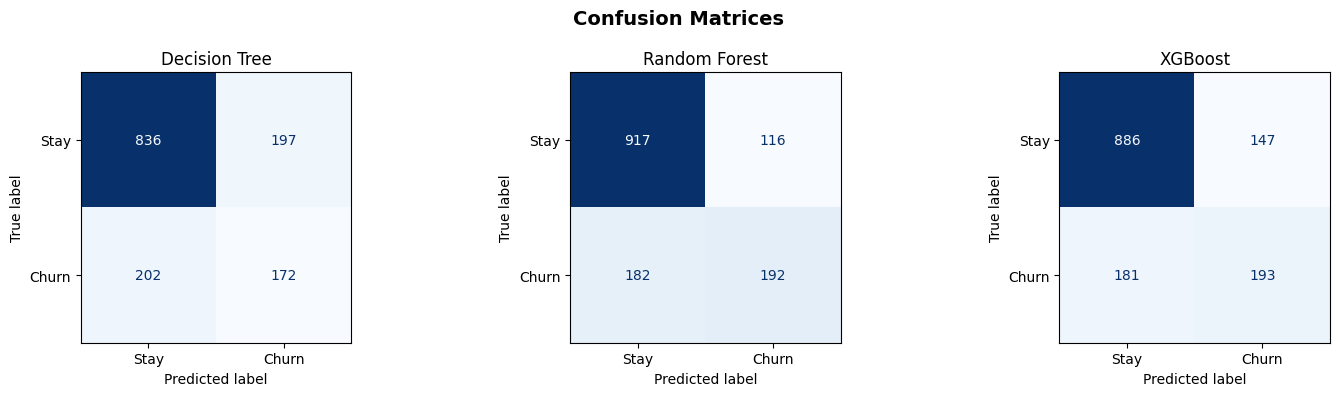

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, trained.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res["cm"],
                                  display_labels=["Stay", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()

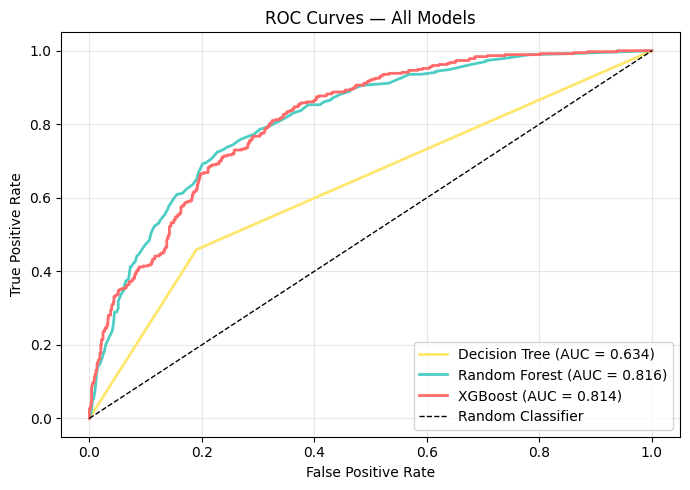

In [12]:
# ROC Curves — all 3 on one plot
plt.figure(figsize=(7, 5))
colors_roc = ["#FFE66D", "#4ECDC4", "#FF6B6B"]

for (name, res), color in zip(trained.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0,1],[0,1], "k--", lw=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Feature Importance (XGBoost)

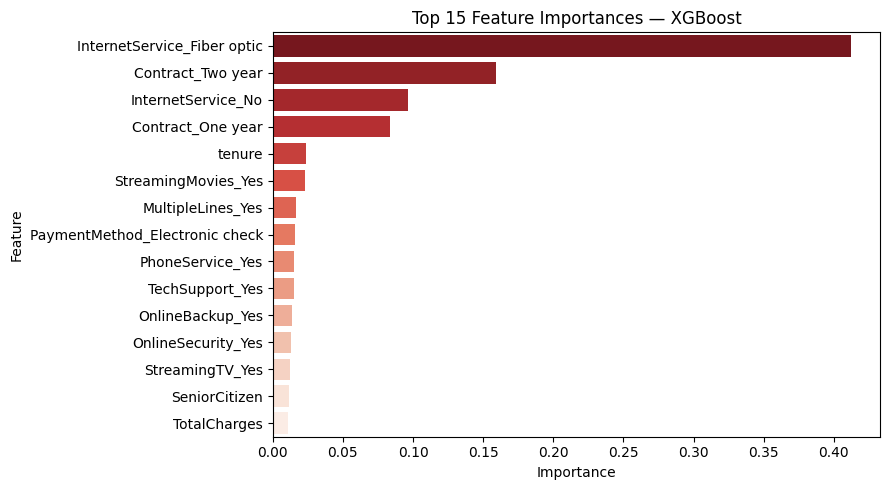


Top 5 most important features:
                    Feature  Importance
InternetService_Fiber optic    0.412365
          Contract_Two year    0.159008
         InternetService_No    0.096571
          Contract_One year    0.083397
                     tenure    0.023526


In [13]:
xgb_model = trained["XGBoost"]["model"]
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="Reds_r")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_df.head(5).to_string(index=False))

## Step 11 — Save Model & Scaler

In [14]:
# Save the best model (XGBoost) and the scaler
best_model = trained["XGBoost"]["model"]
feature_columns = list(X.columns)

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("features.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ Saved:")
print("   model.pkl   — XGBoost trained model")
print("   scaler.pkl  — StandardScaler")
print("   features.pkl — feature column names")
print()
print("⬇️  Download these 3 files from the Colab sidebar (Files tab)")
print("    and place them in the same folder as app.py")

✅ Saved:
   model.pkl   — XGBoost trained model
   scaler.pkl  — StandardScaler
   features.pkl — feature column names

⬇️  Download these 3 files from the Colab sidebar (Files tab)
    and place them in the same folder as app.py


## ✅ Notebook Complete!

You now have:
- Trained and evaluated **3 ML models**
- **XGBoost** selected as best model
- `model.pkl`, `scaler.pkl`, `features.pkl` saved

### Next Steps:
1. **Download** the 3 `.pkl` files from Colab
2. **Run** `app.py` locally: `streamlit run app.py`
3. **Deploy** to Streamlit Cloud (see deployment guide)

> 📌 See the `DEPLOYMENT_GUIDE.md` for step-by-step keys + deployment instructions
